# Phase 2 — Exploratory Data Analysis

## Goal of this notebook
Before we touch any model, we need to **understand the data as a business analyst would**. A model trained on data you don't understand will fail silently. EDA is how we build intuition about drivers of churn and spot data-quality issues before they bite us later.

## Questions we will answer
1. What is the overall churn rate? (Is the data imbalanced?)
2. What is the distribution of each feature? Any weird values?
3. Which features look most correlated with churn?
4. Are there obvious customer segments (e.g. tenure buckets) with very different churn behavior?
5. Any data leakage risks? (e.g. a column that would not exist at prediction time)

We will form hypotheses here and test them rigorously later.

In [1]:
# Standard setup — do this at the top of every notebook
import sys
from pathlib import Path

# Make `src` importable regardless of where the notebook is launched from
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

from src.data.load_data import load_raw_telco, quick_summary

df = load_raw_telco()
quick_summary(df)

Shape: (7043, 21)

Dtypes:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Missing values per column:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract     

## 1. Target variable — churn rate and class balance
**Why this first?** The churn rate dictates almost every downstream decision: the metric we choose (accuracy is misleading on imbalanced data), whether we resample, whether we use class weights, and what a "good" model even looks like.

Churn counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Overall churn rate: 26.54%


C:\Users\egorimanikon\AppData\Local\Temp\ipykernel_22296\1799300115.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Churn", ax=ax, palette=["#2ecc71", "#e74c3c"])


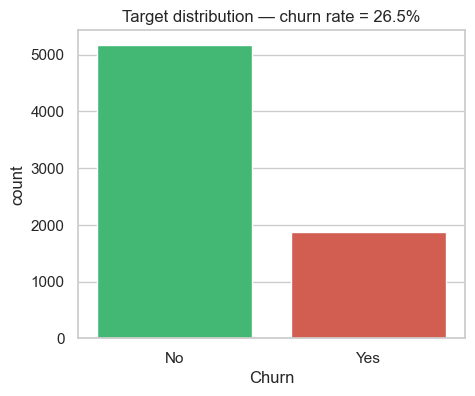

In [2]:
churn_counts = df["Churn"].value_counts()
churn_rate = df["Churn"].eq("Yes").mean()
print(f"Churn counts:\n{churn_counts}")
print(f"\nOverall churn rate: {churn_rate:.2%}")

fig, ax = plt.subplots(figsize=(5, 4))
sns.countplot(data=df, x="Churn", ax=ax, palette=["#2ecc71", "#e74c3c"])
ax.set_title(f"Target distribution — churn rate = {churn_rate:.1%}")
plt.show()

## 2. Data-quality check — the `TotalCharges` trap
IBM's Telco CSV stores `TotalCharges` as an object, not a float. A small number of rows contain a single whitespace character instead of a number. In interviews, catching things like this is a green flag — it shows you read your data before modeling.

In [3]:
print("Dtype of TotalCharges:", df["TotalCharges"].dtype)
blank_mask = df["TotalCharges"].str.strip().eq("")
print(f"Rows with blank TotalCharges: {blank_mask.sum()}")
print("\nInspecting those rows:")
df.loc[blank_mask, ["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

Dtype of TotalCharges: object
Rows with blank TotalCharges: 11

Inspecting those rows:


,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


**Hypothesis to test in the next cell:** the blank `TotalCharges` rows all have `tenure = 0` (brand-new customers whose first invoice has not issued). If so, we can safely impute 0.

In [4]:
# Convert properly now (we will move this to the cleaning module later)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("Nulls after coercion:", df["TotalCharges"].isna().sum())
print("Tenure values where TotalCharges is null:", df.loc[df["TotalCharges"].isna(), "tenure"].unique())

Nulls after coercion: 11
Tenure values where TotalCharges is null: [0]


## 3. Univariate distributions
Plot every numeric and categorical column. You are looking for: skew, outliers, dominant categories, and rare categories that may need to be grouped.

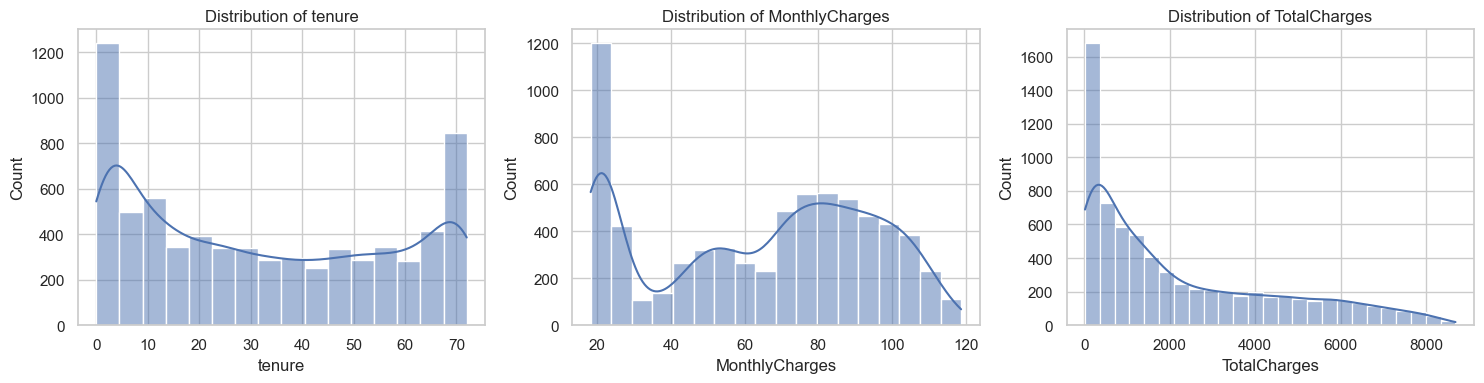

In [5]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(df[col].dropna(), kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

## 4. Bivariate — which features relate to churn?
This is where most of the storytelling for interviews comes from. For each plot, write one sentence of insight below it.

Contract
Month-to-month    0.427097
One year          0.112695
Two year          0.028319
Name: Churn, dtype: float64


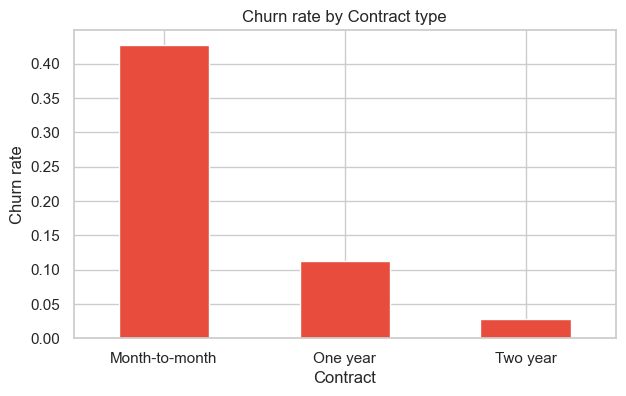

In [6]:
# Churn rate by Contract type
ct = df.groupby("Contract")["Churn"].apply(lambda s: (s == "Yes").mean()).sort_values(ascending=False)
print(ct)

fig, ax = plt.subplots(figsize=(7, 4))
ct.plot(kind="bar", ax=ax, color="#e74c3c")
ax.set_ylabel("Churn rate")
ax.set_title("Churn rate by Contract type")
plt.xticks(rotation=0)
plt.show()

> **Your insight (write it here):** e.g. "Month-to-month customers churn at ~43% vs ~3% for two-year contracts. Contract length is likely the single strongest predictor."

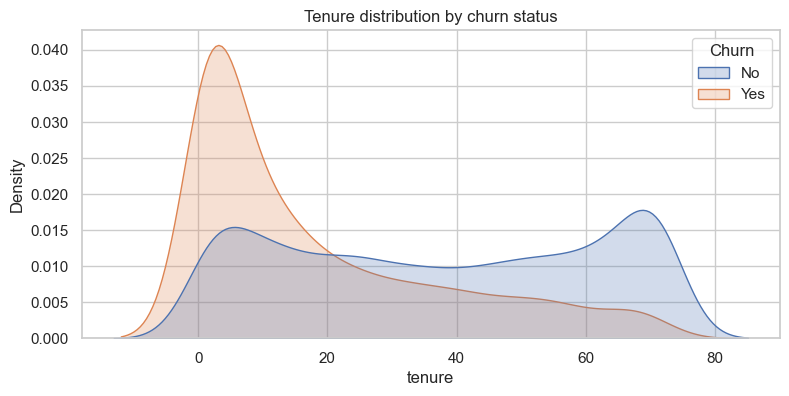

In [7]:
# Tenure vs churn — a classic survival pattern
fig, ax = plt.subplots(figsize=(9, 4))
sns.kdeplot(data=df, x="tenure", hue="Churn", common_norm=False, fill=True, ax=ax)
ax.set_title("Tenure distribution by churn status")
plt.show()

## 5. What to write up
At the end of EDA, you should have a short written summary (3–6 bullets) stating:
- Top 3 features that look predictive and why
- Any data-quality issues to fix in cleaning
- Hypotheses you want to test in modeling ("I expect contract-length x payment-method interaction to matter")

This summary is what you will *talk about* in an interview. Modelers who can't narrate their data don't pass the behavioral-technical blend that Amazon and similar companies use.